# Прогнозирование попадания в сборную по бадминтону

Научно-исследовательская работа, 6 семестр, НИЯУ МИФИ.

Собственный датасет: студенты секции бадминтона заполняли шесть тематических
анкет (мотивация, взаимодействие с тренером, баланс учёбы и спорта, режим
восстановления, соревновательный опыт, метакогнитивные навыки), плюс на
тренировках фиксировались физические тесты — челночный бег, отжимания,
гибкость, точность подач и ударов.

Задача: предсказать, входит ли спортсмен в сборную института.

## Главное про этот датасет

**30 наблюдений и 100 признаков после очистки.** Это соотношение определяет всё
остальное. При таком размере выборки почти любая модель покажет высокое качество
на кросс-валидации, если хоть где-то допустить утечку, — и почти никакая разница
между моделями не будет статистически значимой.

Поэтому ноутбук устроен не как «обучим модель и посмотрим accuracy», а как
последовательная проверка: сколько из полученного качества настоящее.

Основной вывод забегая вперёд: сигнал в данных, похоже, есть, но выборки не
хватает, чтобы утверждать это уверенно. Перестановочный тест даёт p = 0.060 —
наблюдаемое качество почти в точности совпадает с 95-м перцентилем того, что
даёт та же процедура на случайных метках.

## Загрузка и разбор анкет


In [2]:
import sys
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_val_predict,
    cross_val_score, permutation_test_score,
)
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
)

sys.path.append(".")
from src.preprocessing import build_features, TARGET_COLUMN

SEED = 42
TOP_K = 12
N_SPLITS = 5
N_REPEATS = 10        # повторов кросс-валидации
N_PERMUTATIONS = 200  # перестановок в тесте значимости

np.random.seed(SEED)
sns.set_style("whitegrid")

Исходные ответы анкет содержат имена участников и свободные текстовые поля
(место учёбы, описание сторонней активности), поэтому в репозитории лежит только
разобранная числовая матрица. Код разбора — в `src/preprocessing.py`, он
применим к сырым выгрузкам из Google Forms.


In [3]:
RAW_PATH = "data/survey_raw.csv"          # не публикуется
PARSED_PATH = "data/features_parsed.csv"  # то, что лежит в репозитории

try:
    raw = pd.read_csv(RAW_PATH)
    features = build_features(raw)
    target_raw = raw[TARGET_COLUMN]
    print(f"Разобрано из сырых ответов: {features.shape}")
except FileNotFoundError:
    parsed = pd.read_csv(PARSED_PATH)
    features = parsed.drop(columns=["participant_id", TARGET_COLUMN])
    target_raw = parsed[TARGET_COLUMN]
    print(f"Загружена разобранная матрица: {features.shape}")

Загружена разобранная матрица: (52, 101)


### Зачем нужен отдельный разбор

Анкеты собирались через Google Forms с полями свободного ввода, поэтому в
числовых по смыслу колонках лежит что угодно: «6-8», «5-6 часов», «1 год
9 месяцев», «4.3/5», «7к-10к», «1 место шоколадный заяц».

`pd.to_numeric(errors="coerce")` превращает всё это в пропуски, а импутация
медианой затем стирает разницу между «спит 5 часов» и «спит 9 часов». При 30
наблюдениях так теряется заметная часть и без того скудного сигнала.


In [4]:
if "raw" in dir():
    naive = raw.drop(columns=["FullName"], errors="ignore").apply(pd.to_numeric, errors="coerce")
    print(f"Пропусков при наивном to_numeric: {naive.isna().sum().sum()}")
    print(f"Пропусков после разбора:          {features.isna().sum().sum()}")
    print(f"Восстановлено значений:           {naive.isna().sum().sum() - features.isna().sum().sum()}")
else:
    print("Сырые ответы недоступны, сравнение пропускается")

Сырые ответы недоступны, сравнение пропускается


### Целевая переменная

Изначально статус кодировался четырьмя уровнями: 0 — не в сборной, 1-3 — третья,
вторая и основная сборные. При 30 наблюдениях четыре класса дали бы по 6-8
примеров на класс — на таком объёме модель не обучится, а метрики будут
определяться случайностью разбиения. Поэтому задача бинаризована: входит в любую
сборную или нет.

Строки с заполненностью анкеты ниже 67% отбрасываются: у них большинство
признаков пришлось бы импутировать, и наблюдение превратилось бы в набор
медиан.


In [5]:
y_full = (target_raw >= 1).astype(int)

completeness = features.notna().mean(axis=1)
keep = (completeness >= 0.67) & target_raw.notna()

X = features[keep].copy()
y = y_full[keep].to_numpy()

# колонки, полностью пустые или константные, бесполезны
X = X.loc[:, X.notna().sum() > 0]
X = X.loc[:, X.fillna(X.median()).std() > 0]

print(f"Отброшено строк по заполненности: {(~keep).sum()} из {len(features)}")
print(f"Осталось: {X.shape[0]} наблюдений, {X.shape[1]} признаков")
print(f"Классы: в сборной {int(y.sum())}, не в сборной {int((1 - y).sum())}")
print(f"Доля большинства (константный предсказатель): {max(y.mean(), 1 - y.mean()):.3f}")

Отброшено строк по заполненности: 22 из 52
Осталось: 30 наблюдений, 100 признаков
Классы: в сборной 17, не в сборной 13
Доля большинства (константный предсказатель): 0.567


**Соотношение 30 наблюдений на 100 признаков** — это ситуация, в которой любой
достаточно гибкий алгоритм способен идеально подогнаться под обучающую выборку.
Всё дальнейшее построено вокруг того, чтобы не принять такую подгонку за
результат.


## Разведочный анализ


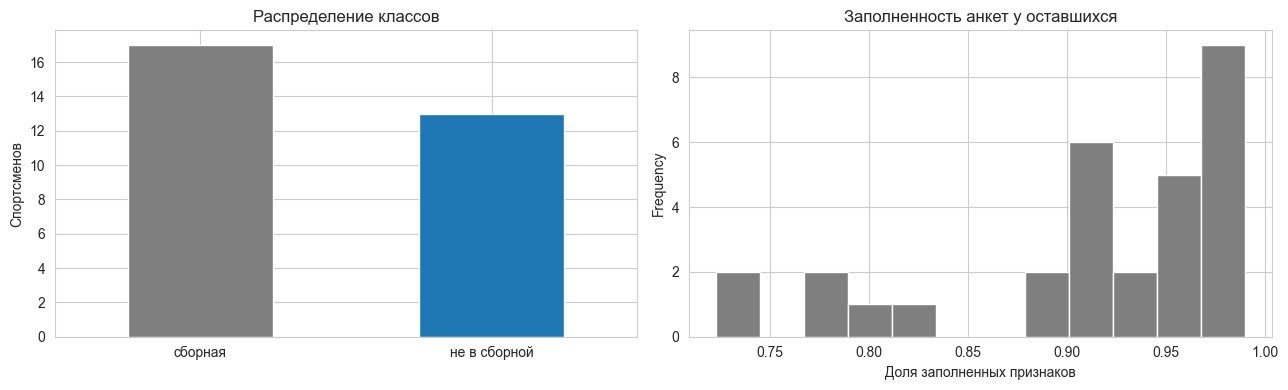

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pd.Series(y).map({0: "не в сборной", 1: "сборная"}).value_counts().plot(
    kind="bar", ax=axes[0], rot=0, color=["tab:gray", "tab:blue"])
axes[0].set_title("Распределение классов")
axes[0].set_ylabel("Спортсменов")

completeness[keep].plot(kind="hist", bins=12, ax=axes[1], color="tab:gray")
axes[1].set_title("Заполненность анкет у оставшихся")
axes[1].set_xlabel("Доля заполненных признаков")

plt.tight_layout()
plt.show()

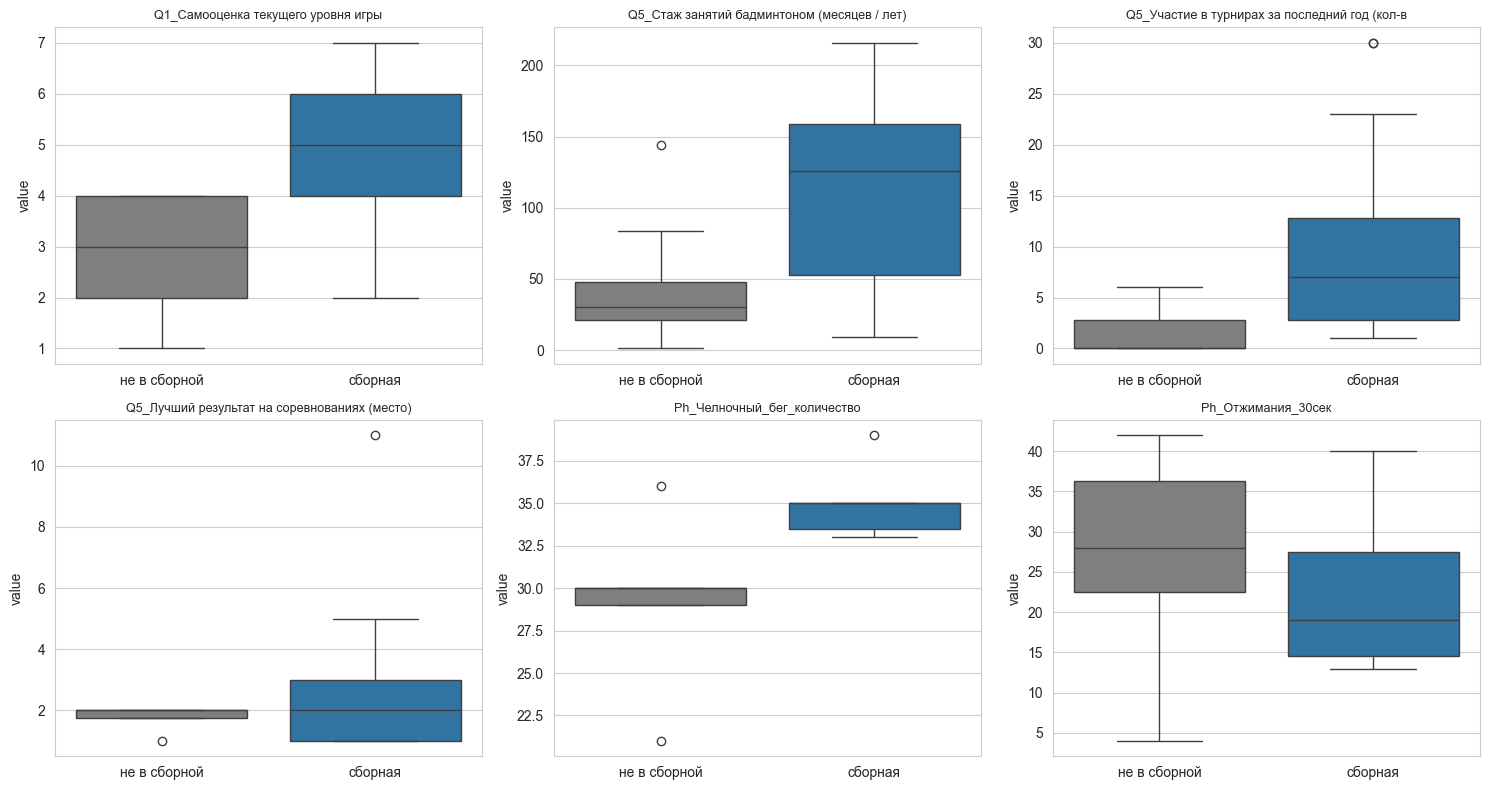

In [7]:
key_features = [c for c in X.columns if any(m in c for m in (
    "Участие в турнирах", "Лучший результат", "Самооценка текущего уровня",
    "Стаж занятий", "Челночный_бег", "Отжимания",
))]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, column in zip(axes.ravel(), key_features[:6]):
    data = pd.DataFrame({"target": y, "value": X[column].values})
    sns.boxplot(data=data, x="target", y="value", hue="target", ax=ax,
                palette=["tab:gray", "tab:blue"], legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["не в сборной", "сборная"])
    ax.set_title(column[:45], fontsize=9)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

Соревновательный опыт и самооценка уровня разделяют группы заметно лучше, чем
физические тесты. Объяснение простое и не требует сложных гипотез: в секцию
приходят люди с очень разной подготовкой, и в сборную попадают те, кто уже играл
в турнирах, — а челночный бег и отжимания у студентов технического вуза
различаются слабо и к специфике бадминтона отношение имеют опосредованное.


## Утечка через отбор признаков

Это центральная часть ноутбука.

В первой версии работы отбор 12 признаков по mutual information выполнялся один
раз на всех данных, и только потом запускалась кросс-валидация. Ошибка неочевидная:
кажется, что отбор признаков — это часть подготовки данных.

На самом деле отбор смотрит на целевую переменную. Признаки выбираются с учётом
всех 30 наблюдений, включая те, что затем окажутся в валидационном фолде. Модель
получает не сами ответы, но информацию о том, какие признаки на них похожи, —
и оценка получается завышенной.

Проверяю это напрямую: считаю одну и ту же схему двумя способами.


In [8]:
# functools.partial, а не lambda: sklearn сериализует пайплайн через pickle,
# а лямбды не пиклятся. random_state фиксируется, иначе оценка mutual
# information шумит от запуска к запуску.
mi_score = partial(mutual_info_classif, random_state=SEED)


def make_pipeline(model):
    """Импутация, масштабирование и отбор признаков — внутри пайплайна.

    Это не стилистика, а требование корректности: всё, что смотрит на данные,
    должно обучаться только на обучающей части фолда.
    """
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("select", SelectKBest(score_func=mi_score, k=TOP_K)),
        ("model", model),
    ])


rf = RandomForestClassifier(
    n_estimators=300, max_depth=4, min_samples_leaf=2,
    class_weight="balanced", random_state=SEED,
)

cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)

# --- вариант A: отбор признаков заранее, на всех данных (так было) ---
X_imputed = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X), columns=X.columns)
selector = SelectKBest(score_func=mi_score, k=TOP_K)
X_preselected = selector.fit_transform(X_imputed, y)

leaky_auc = cross_val_score(rf, X_preselected, y, cv=cv, scoring="roc_auc")
leaky_acc = cross_val_score(rf, X_preselected, y, cv=cv, scoring="accuracy")

# --- вариант B: отбор внутри каждого фолда ---
honest_auc = cross_val_score(make_pipeline(rf), X, y, cv=cv, scoring="roc_auc")
honest_acc = cross_val_score(make_pipeline(rf), X, y, cv=cv, scoring="accuracy")

comparison = pd.DataFrame({
    "отбор до CV": [leaky_acc.mean(), leaky_auc.mean()],
    "отбор внутри фолда": [honest_acc.mean(), honest_auc.mean()],
    "разрыв": [leaky_acc.mean() - honest_acc.mean(), leaky_auc.mean() - honest_auc.mean()],
}, index=["accuracy", "ROC-AUC"])

print(comparison.round(3).to_string())

          отбор до CV  отбор внутри фолда  разрыв
accuracy        0.813               0.627   0.187
ROC-AUC         0.918               0.709   0.209


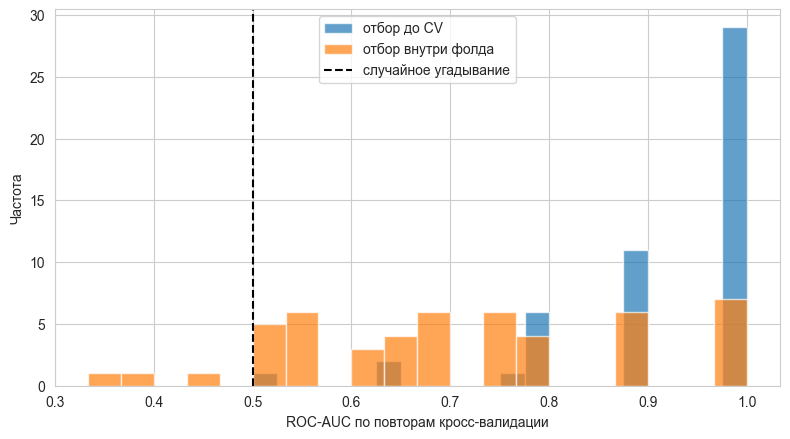

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(leaky_auc, bins=20, alpha=0.7, label="отбор до CV")
ax.hist(honest_auc, bins=20, alpha=0.7, label="отбор внутри фолда")
ax.axvline(0.5, linestyle="--", color="black", label="случайное угадывание")
ax.set_xlabel("ROC-AUC по повторам кросс-валидации")
ax.set_ylabel("Частота")
ax.legend()
plt.tight_layout()
plt.show()

Разрыв между двумя оценками — это цена ошибки: **18.7 процентных пункта
accuracy и 0.209 ROC-AUC**. Первая версия работы ровно на столько завышала
качество модели.

Обе оценки получены на одних и тех же данных, одной и той же моделью, с
одинаковым числом признаков. Единственное отличие — момент, в который
выполняется отбор.

Масштаб стоит соотнести с задачей: константный предсказатель здесь даёт
accuracy 0.567. То есть «завышение» размером 0.187 — это больше, чем весь
запас между константой и любым осмысленным результатом.

## Сравнение с базовыми линиями

Число само по себе ничего не значит, пока не с чем сравнить. Три опорные точки:

- константный предсказатель (всегда «в сборной»);
- решение по одному лучшему признаку;
- логистическая регрессия с L2 — линейная модель как проверка того, нужна ли
  вообще нелинейность.


In [10]:
baselines = {
    "константа (мажоритарный класс)": DummyClassifier(strategy="most_frequent"),
    "логистическая регрессия L2": LogisticRegression(
        C=0.1, class_weight="balanced", max_iter=2000, random_state=SEED),
    "random forest": rf,
}

rows = []
for name, model in baselines.items():
    pipe = make_pipeline(model)
    acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    auc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    f1 = cross_val_score(pipe, X, y, cv=cv, scoring="f1")
    rows.append({
        "модель": name,
        "accuracy": f"{acc.mean():.3f} ± {acc.std():.3f}",
        "ROC-AUC": f"{auc.mean():.3f} ± {auc.std():.3f}",
        "F1": f"{f1.mean():.3f} ± {f1.std():.3f}",
    })

print(pd.DataFrame(rows).to_string(index=False))

                        модель      accuracy       ROC-AUC            F1
константа (мажоритарный класс) 0.567 ± 0.082 0.500 ± 0.000 0.720 ± 0.065
    логистическая регрессия L2 0.640 ± 0.158 0.720 ± 0.192 0.678 ± 0.181
                 random forest 0.627 ± 0.144 0.709 ± 0.175 0.671 ± 0.146


Здесь стоит остановиться на трёх вещах.

**Константный предсказатель выигрывает по F1.** У него F1 = 0.720 против 0.671
у случайного леса. Это не парадокс: он всегда отвечает «в сборной», получает
recall = 1.0 при precision, равной доле класса, и F1 по положительному классу
оказывается высокой. Метрика, которую константа выигрывает, для этой задачи не
годится — смотреть надо на accuracy и ROC-AUC, а F1 приводить макро-усреднением
по обоим классам.

**Логистическая регрессия не уступает лесу**, а по среднему даже чуть выше
(accuracy 0.640 против 0.627, ROC-AUC 0.720 против 0.709). Нелинейность здесь
ничего не покупает — при 30 наблюдениях у леса просто нет данных, чтобы найти
взаимодействия признаков.

**Стандартные отклонения больше разницы между моделями.** Разброс по повторам
кросс-валидации — 0.14-0.19, а вся разница между логрегрессией и лесом — 0.013.
Утверждать, что одна модель лучше другой, на этих данных нельзя.


## Значим ли результат вообще

При 30 наблюдениях разброс кросс-валидации огромен, и превышение над константным
предсказателем на несколько процентных пунктов легко получить на чистом шуме.

Перестановочный тест отвечает на прямой вопрос: если перемешать целевую
переменную, разрушив всякую связь с признаками, — как часто та же процедура даёт
качество не хуже наблюдаемого? Доля таких случаев и есть p-value.

Это единственный способ на таком объёме отличить «модель что-то нашла» от
«процедура умеет подгоняться».


In [11]:
score, permutation_scores, p_value = permutation_test_score(
    make_pipeline(rf), X, y,
    scoring="roc_auc",
    cv=StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED),
    n_permutations=N_PERMUTATIONS,
    random_state=SEED,
    n_jobs=1,   # на Windows joblib копирует sklearn в каждый процесс
)

print(f"ROC-AUC на настоящих метках: {score:.3f}")
print(f"Нулевое распределение: среднее {permutation_scores.mean():.3f}, "
      f"std {permutation_scores.std():.3f}")
print(f"95-й перцентиль нулевого распределения: {np.percentile(permutation_scores, 95):.3f}")
print(f"p-value: {p_value:.3f}")

ROC-AUC на настоящих метках: 0.772
Нулевое распределение: среднее 0.521, std 0.147
95-й перцентиль нулевого распределения: 0.773
p-value: 0.060


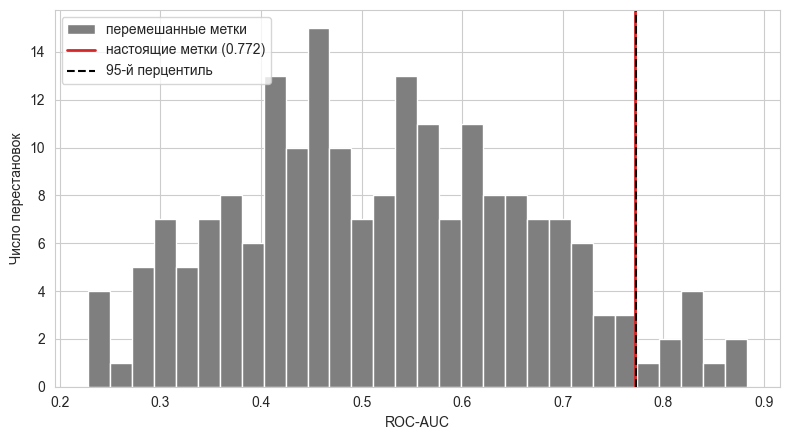

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(permutation_scores, bins=30, color="tab:gray", label="перемешанные метки")
ax.axvline(score, color="tab:red", linewidth=2, label=f"настоящие метки ({score:.3f})")
ax.axvline(np.percentile(permutation_scores, 95), linestyle="--", color="black",
           label="95-й перцентиль")
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Число перестановок")
ax.legend()
plt.tight_layout()
plt.show()

Наблюдаемое качество — 0.772 при 95-м перцентиле нулевого распределения 0.773.
Совпадение до третьего знака: результат ровно на границе значимости, p = 0.060.
Формально гипотезу об отсутствии связи на уровне 0.05 отвергнуть нельзя.

Отдельно стоит заметить, что перестановочный тест считается на одном разбиении,
и наблюдаемые здесь 0.772 выше, чем среднее по 10 повторам кросс-валидации
(0.709). То есть конкретно это разбиение оказалось удачным — и даже оно не
дотягивает до значимости.

Разброс нулевого распределения (std 0.147) показывает масштаб проблемы: на 30
наблюдениях случайные метки регулярно дают ROC-AUC выше 0.7. Любая цифра в этом
диапазоне без перестановочного теста ничего не значит.

Правильная формулировка вывода: данные не противоречат наличию связи, но и не
доказывают её. Утверждать, что модель предсказывает попадание в сборную, на
30 наблюдениях нельзя.

## Какие признаки отбираются устойчиво

Если отбор признаков делать внутри фолда, набор в разных фолдах будет разным.
Насколько разным — само по себе диагностика: признак, попадающий в топ почти
всегда, отражает устойчивую закономерность; признак, всплывающий в трети
фолдов, скорее шум конкретного разбиения.


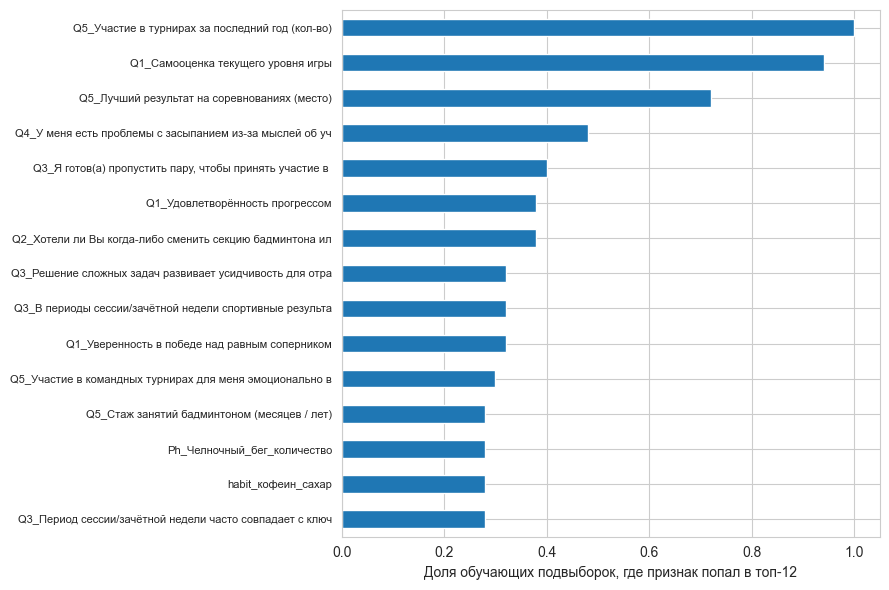

Q5_Участие в турнирах за последний год (кол-во)                                                              1.00
Q1_Самооценка текущего уровня игры                                                                           0.94
Q5_Лучший результат на соревнованиях (место)                                                                 0.72
Q4_У меня есть проблемы с засыпанием из-за мыслей об учебе/ тренировках                                      0.48
Q3_Я готов(а) пропустить пару, чтобы принять участие в важном турнире                                        0.40
Q1_Удовлетворённость прогрессом                                                                              0.38
Q2_Хотели ли Вы когда-либо сменить секцию бадминтона или тренера?                                            0.38
Q3_Решение сложных задач развивает усидчивость для отработки техники                                         0.32
Q3_В периоды сессии/зачётной недели спортивные результаты падают                        

In [13]:
from collections import Counter

counter = Counter()
n_fits = 0

stability_cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=10, random_state=SEED)

for train_idx, _ in stability_cv.split(X, y):
    pipe = make_pipeline(rf).fit(X.iloc[train_idx], y[train_idx])
    mask = pipe.named_steps["select"].get_support()
    counter.update(X.columns[mask])
    n_fits += 1

stability = (pd.Series(counter) / n_fits).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
stability.head(15)[::-1].plot(kind="barh", ax=ax, color="tab:blue")
ax.set_xlabel(f"Доля обучающих подвыборок, где признак попал в топ-{TOP_K}")
labels = [label.get_text()[:55] for label in ax.get_yticklabels()]
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(labels, fontsize=8)
plt.tight_layout()
plt.show()

print(stability.head(15).to_string())

Устойчивых признаков оказалось всего три:

| Признак | Доля подвыборок |
|---|---|
| Участие в турнирах за последний год | 100% |
| Самооценка текущего уровня игры | 94% |
| Лучший результат на соревнованиях | 72% |

Дальше обрыв: следующий признак попадает в топ-12 менее чем в половине случаев
(48%), а хвост списка держится на уровне 28-32% — это уже случайность
конкретного разбиения, а не закономерность.

Из 100 признаков анкеты содержательный вклад дают три, и все три описывают одно
и то же: соревновательный опыт и то, как спортсмен сам оценивает свой уровень.
Физические тесты в устойчивую тройку не входят вовсе — челночный бег появляется
в 28% подвыборок, наравне с шумом.

Причинность отсюда не следует: участие в турнирах может быть и причиной
попадания в сборную, и его следствием. По данным одного среза направление связи
неразличимо.

## Финальная модель и матрица ошибок

Модель обучается и оценивается через `cross_val_predict` — предсказание для
каждого наблюдения делается моделью, которая его не видела.


              precision    recall  f1-score   support

не в сборной      0.455     0.385     0.417        13
     сборная      0.579     0.647     0.611        17

    accuracy                          0.533        30
   macro avg      0.517     0.516     0.514        30
weighted avg      0.525     0.533     0.527        30



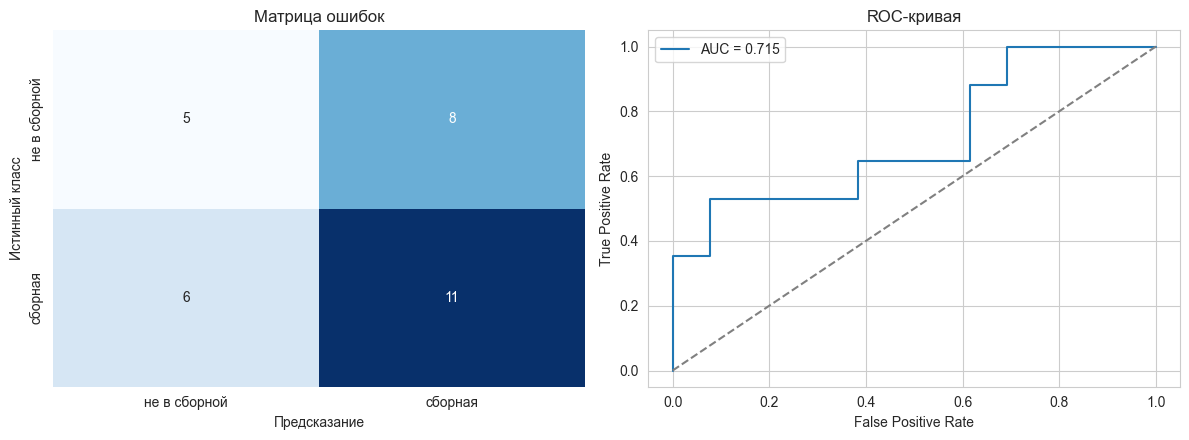

In [14]:
final_pipe = make_pipeline(rf)
single_cv = StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED)

proba = cross_val_predict(final_pipe, X, y, cv=single_cv, method="predict_proba")[:, 1]
pred = (proba >= 0.5).astype(int)

print(classification_report(y, pred, target_names=["не в сборной", "сборная"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(confusion_matrix(y, pred), annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["не в сборной", "сборная"],
            yticklabels=["не в сборной", "сборная"], ax=axes[0])
axes[0].set_xlabel("Предсказание")
axes[0].set_ylabel("Истинный класс")
axes[0].set_title("Матрица ошибок")

fpr, tpr, _ = roc_curve(y, proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y, proba):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC-кривая")
axes[1].legend()

plt.tight_layout()
plt.show()

Здесь видно то, что не показывает ROC-AUC: **accuracy бинарных предсказаний
равна 0.533, то есть ниже константного предсказателя (0.567)**. Модель, которая
по ранжированию выглядит небесполезной, при пороге 0.5 работает хуже, чем ответ
«все в сборной».

Противоречия нет. ROC-AUC оценивает порядок объектов и не зависит от порога,
accuracy — конкретные решения при пороге 0.5. Модель кое-как упорядочивает
спортсменов, но её вероятности не откалиброваны, и разрез по 0.5 попадает
неудачно. Подбирать порог по тем же 30 наблюдениям бессмысленно — это будет
подгонка.

ROC-кривая на 30 точках ступенчатая, каждая ступенька — один спортсмен.
Смещение одного человека через порог заметно двигает AUC. Это стоит держать в
голове, глядя на любую метрику здесь.

## Выводы

**Про методику.** Отбор признаков до кросс-валидации завышал accuracy на 18.7
процентных пункта, ROC-AUC — на 0.209. Данные, модель и число признаков при
этом одинаковы, отличается только момент отбора. На выборке из 30 наблюдений и
100 признаков это не редкая тонкость, а решающий фактор: величина завышения
превышает весь запас между константным предсказателем и осмысленным
результатом.

**Про результат.** Честная оценка (accuracy 0.627, ROC-AUC 0.709) превышает
константный предсказатель, но перестановочный тест даёт p = 0.060 при
наблюдаемом ROC-AUC 0.772 и 95-м перцентиле нулевого распределения 0.773.
Связь не доказана. Более того, бинарные предсказания при пороге 0.5 дают
accuracy 0.533 — ниже константы.

**Про модели.** Логистическая регрессия не уступает случайному лесу, а
стандартные отклонения по повторам кросс-валидации (0.14-0.19) на порядок
больше разницы между моделями. Выбирать модель на этих данных не из чего.

**Про предметную область.** Из 100 признаков анкеты устойчиво отбираются три:
участие в турнирах, самооценка уровня игры, лучший результат на соревнованиях.
Физические тесты не входят — ожидаемо для студенческой секции, где разброс
общефизической подготовки невелик, а разброс игрового опыта велик. Направление
причинности по данным одного среза установить нельзя.

**Что нужно, чтобы работа дала надёжный ответ.** В первую очередь данные: при
100 признаках для устойчивого вывода нужно хотя бы 150-200 наблюдений, то есть
сбор по нескольким вузам или несколько сезонов подряд. Второе — сократить
анкету: большая часть вопросов не попадает в устойчивый отбор ни разу и только
увеличивает пространство поиска. Третье — повторные измерения одних и тех же
спортсменов, что позволило бы смотреть на динамику и приблизиться к вопросу о
причинности.